# 🎬 Movie Recommendation System
## End-to-End Pipeline: EDA → Preprocessing → Merging → Model Training

**Datasets:**
- `african_movies_raw.csv` — Scraped from IMDb (499 African movies)
- `movies.csv` — MovieLens movies (10,329 movies)
- `ratings.csv` — MovieLens ratings (105,339 ratings from 668 users)

**Pipeline:**
1. Load & Explore all three datasets (EDA)
2. Clean & Preprocess each dataset
3. Merge into unified dataset
4. Build Content-Based Filtering model
5. Build Collaborative Filtering model (SVD)
6. Build Hybrid Recommender
7. Evaluate models
8. Save model artifacts

In [ ]:
!pip install numpy==1.26.4
!pip uninstall scikit-surprise -y
!pip install scikit-surprise

Found existing installation: scikit-surprise 1.1.4
Uninstalling scikit-surprise-1.1.4:
  Successfully uninstalled scikit-surprise-1.1.4
  Using cached scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Base paths
DRIVE_BASE     = '/content/drive/MyDrive/movie_recommender'
RAW_PATH       = f'{DRIVE_BASE}/data/raw/'
PROCESSED_PATH = f'{DRIVE_BASE}/data/processed/'
MODELS_PATH    = f'{DRIVE_BASE}/models/'

# Create folders if they don't exist
import os
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

print('✅ Paths configured!')

✅ Paths configured!


In [ ]:
# At the top of your notebook add these
import os
os.makedirs('/content/drive/MyDrive/movie_recommender/data/processed', exist_ok=True)
os.makedirs('/content/drive/MyDrive/movie_recommender/models', exist_ok=True)

# Then use these as your base paths
PROCESSED_PATH = '/content/drive/MyDrive/movie_recommender/data/processed/'
MODELS_PATH    = '/content/drive/MyDrive/movie_recommender/models/'

# SECTION 1: Imports & Setup of Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Collaborative filtering
from surprise import Dataset, Reader, SVD
from surprise import accuracy
from surprise.model_selection import cross_validate, train_test_split as surprise_split

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

✅ All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 1.26.4


# SECTION 2: Load Datasets

In [ ]:
# ──  data paths ──
AFRICAN_PATH = '/content/drive/MyDrive/movie_recommender/data/raw/african_movies_raw.csv'
MOVIES_PATH  = '/content/drive/MyDrive/movie_recommender/data/raw/movies.csv'
RATINGS_PATH = '/content/drive/MyDrive/movie_recommender/data/raw/ratings.csv'


african_df = pd.read_csv(AFRICAN_PATH)
movies_df  = pd.read_csv(MOVIES_PATH)
ratings_df = pd.read_csv(RATINGS_PATH)

print('=== Dataset Shapes ===')
print(f'African Movies : {african_df.shape}')
print(f'MovieLens Movies : {movies_df.shape}')
print(f'MovieLens Ratings : {ratings_df.shape}')

=== Dataset Shapes ===
African Movies : (499, 8)
MovieLens Movies : (10329, 3)
MovieLens Ratings : (105339, 4)


# SECTION 3: EDA — African Movies Dataset

In [ ]:
print('=== African Movies — First 5 Rows ===')
african_df.head()

=== African Movies — First 5 Rows ===


,title,year,rating,votes,genre,description,country,url
0,Behind the Scenes,NaN,7.8,54,NaN,"Aderonke Faniran, a mother of two and successful real estate mogul, is loved...",Nigeria,https://www.imdb.com/title/tt38953750/
1,The Creek,NaN,9.8,6,NaN,NaN,Nigeria,https://www.imdb.com/title/tt38345778/
2,Oversabi Aunty,NaN,7.2,7,NaN,"A zealous church usher's mission to ""fix"" everyone backfires as her moral cr...",Nigeria,https://www.imdb.com/title/tt38999905/
3,Colours of Fire,NaN,7.8,9,NaN,When a warrior is sent out to hunt a beast believed to be unleashed by his c...,Nigeria,https://www.imdb.com/title/tt38673107/
4,Gingerrr,NaN,NaN,NaN,NaN,When a high-stakes heist becomes their only hope of escape from the life the...,Nigeria,https://www.imdb.com/title/tt38061242/


In [ ]:
print('=== Data Types & Null Counts ===')
print(african_df.info())
print('\n=== Missing Values ===')
missing = african_df.isnull().sum()
missing_pct = (missing / len(african_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

=== Data Types & Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        499 non-null    object 
 1   year         0 non-null      float64
 2   rating       295 non-null    float64
 3   votes        295 non-null    object 
 4   genre        0 non-null      float64
 5   description  363 non-null    object 
 6   country      499 non-null    object 
 7   url          499 non-null    object 
dtypes: float64(3), object(5)
memory usage: 31.3+ KB
None

=== Missing Values ===


,Missing Count,Missing %
title,0,0.00
year,499,100.00
rating,204,40.88
votes,204,40.88
genre,499,100.00
description,136,27.25
country,0,0.00
url,0,0.00


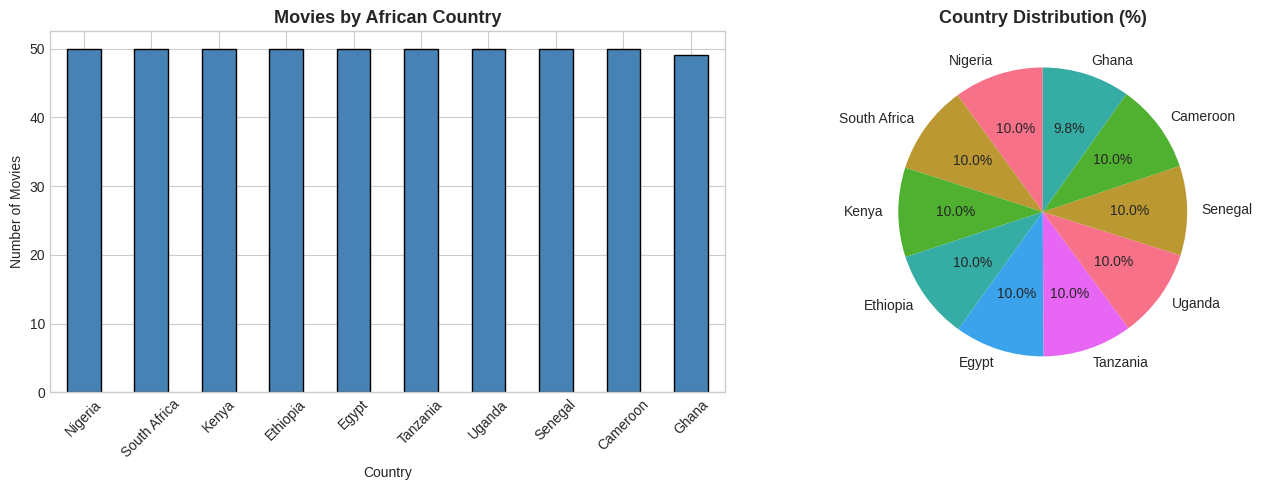

country
Nigeria         50
South Africa    50
Kenya           50
Ethiopia        50
Egypt           50
Tanzania        50
Uganda          50
Senegal         50
Cameroon        50
Ghana           49
Name: count, dtype: int64


In [ ]:
# Country distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
country_counts = african_df['country'].value_counts()
country_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Movies by African Country', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Movies')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
country_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Country Distribution (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{PROCESSED_PATH}eda_country_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(country_counts)

Movies with ratings: 295 / 499
Rating stats:
count    295.000000
mean       6.620339
std        1.443350
min        2.100000
25%        5.600000
50%        6.800000
75%        7.550000
max        9.800000
Name: rating, dtype: float64


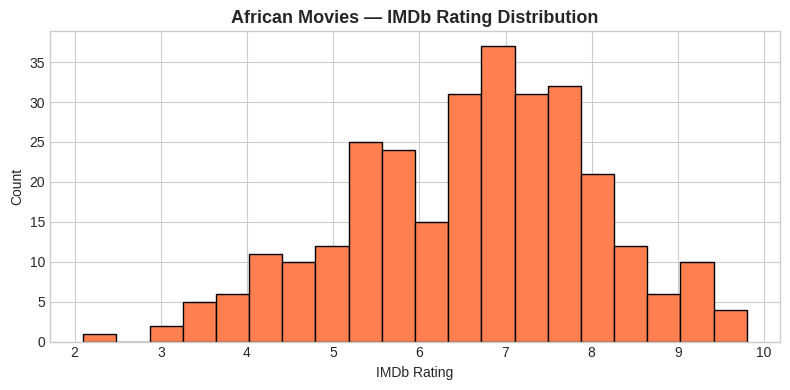

In [ ]:
# Rating distribution for African movies
african_rated = african_df.dropna(subset=['rating'])
print(f'Movies with ratings: {len(african_rated)} / {len(african_df)}')
print(f'Rating stats:\n{african_rated["rating"].describe()}')

plt.figure(figsize=(8, 4))
plt.hist(african_rated['rating'], bins=20, color='coral', edgecolor='black')
plt.title('African Movies — IMDb Rating Distribution', fontsize=13, fontweight='bold')
plt.xlabel('IMDb Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f'{PROCESSED_PATH}eda_country_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# SECTION 4: EDA — MovieLens Datasets

In [ ]:
print('=== MovieLens Movies — First 5 Rows ===')
movies_df.head()

=== MovieLens Movies — First 5 Rows ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
print('=== MovieLens Ratings — First 5 Rows ===')
ratings_df.head()

=== MovieLens Ratings — First 5 Rows ===


,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [ ]:
print('=== Key Stats ===')
print(f'Total movies       : {movies_df["movieId"].nunique():,}')
print(f'Total users        : {ratings_df["userId"].nunique():,}')
print(f'Total ratings      : {len(ratings_df):,}')
print(f'Rating range       : {ratings_df["rating"].min()} — {ratings_df["rating"].max()}')
print(f'Avg rating         : {ratings_df["rating"].mean():.2f}')
print(f'Avg ratings/user   : {len(ratings_df) / ratings_df["userId"].nunique():.1f}')
print(f'Avg ratings/movie  : {len(ratings_df) / ratings_df["movieId"].nunique():.1f}')

=== Key Stats ===
Total movies       : 10,329
Total users        : 668
Total ratings      : 105,339
Rating range       : 0.5 — 5.0
Avg rating         : 3.52
Avg ratings/user   : 157.7
Avg ratings/movie  : 10.2


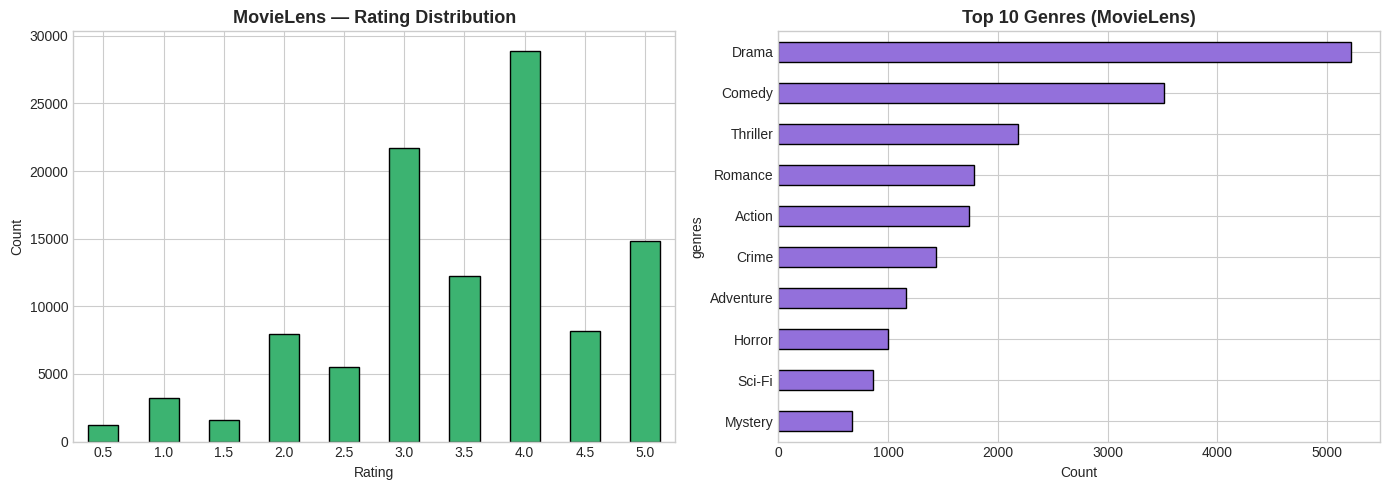

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
ratings_df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='black'
)
axes[0].set_title('MovieLens — Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Top 10 genres
all_genres = movies_df['genres'].str.split('|').explode()
all_genres = all_genres[all_genres != '(no genres listed)']
genre_counts = all_genres.value_counts().head(10)
genre_counts.plot(kind='barh', ax=axes[1], color='mediumpurple', edgecolor='black')
axes[1].set_title('Top 10 Genres (MovieLens)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{PROCESSED_PATH}eda_movielens.png', dpi=150, bbox_inches='tight')
plt.show()

Ratings per user stats:
count     668.000000
mean      157.693114
std       319.712512
min        20.000000
25%        35.000000
50%        70.500000
75%       153.000000
max      5678.000000
dtype: float64


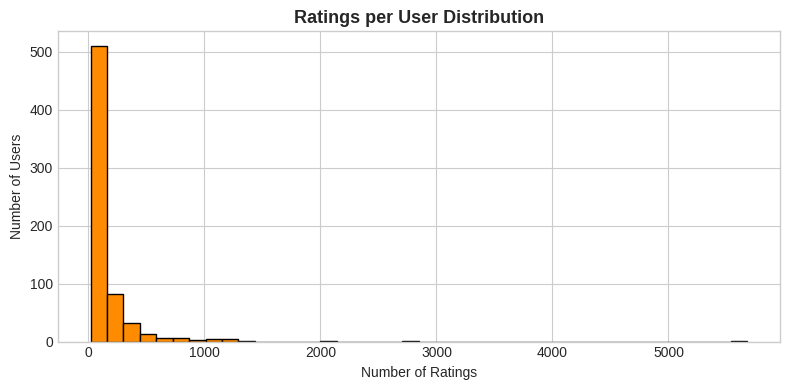

In [ ]:
# Ratings per user distribution
ratings_per_user = ratings_df.groupby('userId').size()
print(f'Ratings per user stats:\n{ratings_per_user.describe()}')

plt.figure(figsize=(8, 4))
plt.hist(ratings_per_user, bins=40, color='darkorange', edgecolor='black')
plt.title('Ratings per User Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig(f'{PROCESSED_PATH}eda_ratings_per_user.png', dpi=150, bbox_inches='tight')
plt.show()

# SECTION 5: Data Preprocessing

In [ ]:
print('=== Preprocessing African Movies Dataset ===')

af = african_df.copy()

# 1. Remove duplicate titles
before = len(af)
af = af.drop_duplicates(subset='title', keep='first')
print(f'Duplicates removed: {before - len(af)}')

# 2. Clean title — strip whitespace
af['title'] = af['title'].str.strip()

# 3. Fill missing descriptions
af['description'] = af['description'].fillna('No description available')

# 4. Fill missing genre using country as fallback label
# Genre was not scraped (all null) — we'll use 'African' + country as genre proxy
af['genre'] = af['country'].apply(lambda c: f'African, {c} Cinema')

# 5. Fill missing ratings with median
median_rating = af['rating'].median()
af['rating'] = af['rating'].fillna(median_rating)
print(f'Missing ratings filled with median: {median_rating}')

# 6. Fill missing year with 0 (unknown)
af['year'] = af['year'].fillna(0).astype(int)

# 7. Create a 'source' column to track origin
af['source'] = 'African_IMDb'

# 8. Assign a movieId starting from 200000 to avoid clash with MovieLens IDs
af = af.reset_index(drop=True)
af['movieId'] = af.index + 200001

# 9. Select and rename relevant columns
af_clean = af[['movieId', 'title', 'genre', 'description', 'rating',
               'year', 'country', 'source', 'url']].copy()

print(f'\nCleaned African dataset shape: {af_clean.shape}')
print(f'Remaining nulls:\n{af_clean.isnull().sum()}')
af_clean.head()

=== Preprocessing African Movies Dataset ===
Duplicates removed: 0
Missing ratings filled with median: 6.8

Cleaned African dataset shape: (499, 9)
Remaining nulls:
movieId        0
title          0
genre          0
description    0
rating         0
year           0
country        0
source         0
url            0
dtype: int64


,movieId,title,genre,description,rating,year,country,source,url
0,200001,Behind the Scenes,"African, Nigeria Cinema","Aderonke Faniran, a mother of two and successful real estate mogul, is loved...",7.8,0,Nigeria,African_IMDb,https://www.imdb.com/title/tt38953750/
1,200002,The Creek,"African, Nigeria Cinema",No description available,9.8,0,Nigeria,African_IMDb,https://www.imdb.com/title/tt38345778/
2,200003,Oversabi Aunty,"African, Nigeria Cinema","A zealous church usher's mission to ""fix"" everyone backfires as her moral cr...",7.2,0,Nigeria,African_IMDb,https://www.imdb.com/title/tt38999905/
3,200004,Colours of Fire,"African, Nigeria Cinema",When a warrior is sent out to hunt a beast believed to be unleashed by his c...,7.8,0,Nigeria,African_IMDb,https://www.imdb.com/title/tt38673107/
4,200005,Gingerrr,"African, Nigeria Cinema",When a high-stakes heist becomes their only hope of escape from the life the...,6.8,0,Nigeria,African_IMDb,https://www.imdb.com/title/tt38061242/


In [ ]:
print('=== Preprocessing MovieLens Movies Dataset ===')

ml = movies_df.copy()

# 1. Extract year from title e.g. "Toy Story (1995)" -> year=1995
ml['year'] = ml['title'].str.extract(r'\((\d{4})\)$').astype(float).fillna(0).astype(int)

# 2. Clean title — remove year part
ml['title'] = ml['title'].str.replace(r'\s*\(\d{4}\)\s*$', '', regex=True).str.strip()

# 3. Clean genres — replace pipe with comma
ml['genre'] = ml['genres'].str.replace('|', ', ', regex=False)
ml['genre'] = ml['genre'].str.replace('(no genres listed)', 'Unknown', regex=False)

# 4. Add description placeholder (MovieLens has no descriptions)
ml['description'] = 'No description available'

# 5. Add source and country columns
ml['source'] = 'MovieLens'
ml['country'] = 'Unknown'
ml['rating'] = np.nan   # Will be derived from ratings_df later
ml['url'] = np.nan

# 6. Select relevant columns
ml_clean = ml[['movieId', 'title', 'genre', 'description', 'rating',
               'year', 'country', 'source', 'url']].copy()

print(f'Cleaned MovieLens movies shape: {ml_clean.shape}')
print(f'Remaining nulls:\n{ml_clean.isnull().sum()}')
ml_clean.head()

=== Preprocessing MovieLens Movies Dataset ===
Cleaned MovieLens movies shape: (10329, 9)
Remaining nulls:
movieId            0
title              0
genre              0
description        0
rating         10329
year               0
country            0
source             0
url            10329
dtype: int64


,movieId,title,genre,description,rating,year,country,source,url
0,1,Toy Story,"Adventure, Animation, Children, Comedy, Fantasy",No description available,NaN,1995,Unknown,MovieLens,NaN
1,2,Jumanji,"Adventure, Children, Fantasy",No description available,NaN,1995,Unknown,MovieLens,NaN
2,3,Grumpier Old Men,"Comedy, Romance",No description available,NaN,1995,Unknown,MovieLens,NaN
3,4,Waiting to Exhale,"Comedy, Drama, Romance",No description available,NaN,1995,Unknown,MovieLens,NaN
4,5,Father of the Bride Part II,Comedy,No description available,NaN,1995,Unknown,MovieLens,NaN


In [ ]:
# Compute average rating per movie from ratings_df
avg_ratings = ratings_df.groupby('movieId')['rating'].mean().round(2).reset_index()
avg_ratings.columns = ['movieId', 'avg_rating']

# Merge into MovieLens movies
ml_clean = ml_clean.merge(avg_ratings, on='movieId', how='left')
ml_clean['rating'] = ml_clean['avg_rating'].fillna(ml_clean['avg_rating'].median())
ml_clean = ml_clean.drop(columns=['avg_rating'])

print('Average ratings merged into MovieLens movies')
print(f'Rating range: {ml_clean["rating"].min():.2f} — {ml_clean["rating"].max():.2f}')
ml_clean[['movieId', 'title', 'rating']].head()

Average ratings merged into MovieLens movies
Rating range: 0.50 — 5.00


,movieId,title,rating
0,1,Toy Story,3.91
1,2,Jumanji,3.35
2,3,Grumpier Old Men,3.19
3,4,Waiting to Exhale,2.82
4,5,Father of the Bride Part II,3.25


# SECTION 6: Merge Datasets

In [ ]:
print('=== Merging African + MovieLens Movies ===')

# Concatenate both cleaned datasets
merged_df = pd.concat([ml_clean, af_clean], ignore_index=True)

# Final deduplication by title (case-insensitive)
merged_df['title_lower'] = merged_df['title'].str.lower().str.strip()
merged_df = merged_df.drop_duplicates(subset='title_lower', keep='first')
merged_df = merged_df.drop(columns=['title_lower'])
merged_df = merged_df.reset_index(drop=True)

print(f'MovieLens movies   : {len(ml_clean):,}')
print(f'African movies     : {len(af_clean):,}')
print(f'Merged total       : {len(merged_df):,}')
print(f'Source breakdown:\n{merged_df["source"].value_counts()}')
merged_df.head()

=== Merging African + MovieLens Movies ===
MovieLens movies   : 10,329
African movies     : 499
Merged total       : 10,482
Source breakdown:
source
MovieLens       10009
African_IMDb      473
Name: count, dtype: int64


,movieId,title,genre,description,rating,year,country,source,url
0,1,Toy Story,"Adventure, Animation, Children, Comedy, Fantasy",No description available,3.91,1995,Unknown,MovieLens,NaN
1,2,Jumanji,"Adventure, Children, Fantasy",No description available,3.35,1995,Unknown,MovieLens,NaN
2,3,Grumpier Old Men,"Comedy, Romance",No description available,3.19,1995,Unknown,MovieLens,NaN
3,4,Waiting to Exhale,"Comedy, Drama, Romance",No description available,2.82,1995,Unknown,MovieLens,NaN
4,5,Father of the Bride Part II,Comedy,No description available,3.25,1995,Unknown,MovieLens,NaN


In [ ]:
# Save merged movies dataset
merged_df.to_csv(f'{PROCESSED_PATH}movies_merged.csv', index=False)

# Save ratings as-is (only MovieLens has ratings)
ratings_df.to_csv(f'{PROCESSED_PATH}ratings_clean.csv', index=False)

print(f'✅ Saved: {PROCESSED_PATH}movies_merged.csv')
print(f'✅ Saved: {PROCESSED_PATH}ratings_clean.csv')
print(f'Merged dataset shape: {merged_df.shape}')

✅ Saved: /content/drive/MyDrive/movie_recommender/data/processed/movies_merged.csv
✅ Saved: /content/drive/MyDrive/movie_recommender/data/processed/ratings_clean.csv
Merged dataset shape: (10482, 9)


# SECTION 7: Feature Engineering for Content-Based Filtering

In [ ]:
print('=== Building Content Feature String ===')

def build_content_string(row):
    """Combine title, genre, description and country into one text string."""
    parts = []
    if pd.notna(row['title']):
        parts.append(str(row['title']))
    if pd.notna(row['genre']):
        parts.append(str(row['genre']))
    if pd.notna(row['description']) and row['description'] != 'No description available':
        parts.append(str(row['description']))
    if pd.notna(row['country']) and row['country'] != 'Unknown':
        parts.append(str(row['country']))
    return ' '.join(parts).lower()

merged_df['content'] = merged_df.apply(build_content_string, axis=1)

print('Sample content strings:')
for i in range(3):
    print(f'  [{merged_df.iloc[i]["title"]}]: {merged_df.iloc[i]["content"][:100]}...')

=== Building Content Feature String ===
Sample content strings:
  [Toy Story]: toy story adventure, animation, children, comedy, fantasy...
  [Jumanji]: jumanji adventure, children, fantasy...
  [Grumpier Old Men]: grumpier old men comedy, romance...


# SECTION 8: Content-Based Filtering Model

In [ ]:
print('=== Building TF-IDF Matrix ===')

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=1
)

tfidf_matrix = tfidf.fit_transform(merged_df['content'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'  → {tfidf_matrix.shape[0]:,} movies × {tfidf_matrix.shape[1]:,} features')

=== Building TF-IDF Matrix ===
TF-IDF matrix shape: (10482, 5000)
  → 10,482 movies × 5,000 features


In [ ]:
print('=== Computing Cosine Similarity Matrix ===')
print('⏳ This may take a moment for large datasets...')

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f'Cosine similarity matrix shape: {cosine_sim.shape}')

# Build title-to-index mapping
title_to_idx = pd.Series(merged_df.index, index=merged_df['title'].str.lower()).drop_duplicates()
print(f'Title index mapping created: {len(title_to_idx):,} entries')

=== Computing Cosine Similarity Matrix ===
⏳ This may take a moment for large datasets...
Cosine similarity matrix shape: (10482, 10482)
Title index mapping created: 10,482 entries


In [ ]:
def get_content_recommendations(title, n=10):
    """
    Get top-N content-based recommendations for a given movie title.

    Args:
        title (str): Movie title to get recommendations for
        n (int): Number of recommendations to return

    Returns:
        DataFrame: Top N similar movies
    """
    title_lower = title.lower().strip()

    if title_lower not in title_to_idx:
        print(f'❌ Movie "{title}" not found in dataset.')
        # Try partial match
        matches = [t for t in title_to_idx.index if title_lower in t]
        if matches:
            print(f'   Did you mean: {matches[:3]}')
        return None

    idx = title_to_idx[title_lower]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]  # Skip self

    movie_indices = [i[0] for i in sim_scores]
    scores = [round(i[1], 4) for i in sim_scores]

    result = merged_df.iloc[movie_indices][['title', 'genre', 'rating', 'country', 'source']].copy()
    result['similarity_score'] = scores
    return result.reset_index(drop=True)


# ── Test content-based recommender ──
print('=== Content-Based Recommendations Test ===')
print('\n🎬 Movies similar to "Toy Story":')
recs = get_content_recommendations('Toy Story', n=5)
if recs is not None:
    print(recs.to_string(index=False))

=== Content-Based Recommendations Test ===

🎬 Movies similar to "Toy Story":
                         title                                                 genre  rating country    source  similarity_score
                   Toy Story 2       Adventure, Animation, Children, Comedy, Fantasy    3.91 Unknown MovieLens            1.0000
                   Toy Story 3 Adventure, Animation, Children, Comedy, Fantasy, IMAX    4.14 Unknown MovieLens            0.9172
We're Back! A Dinosaur's Story               Adventure, Animation, Children, Fantasy    4.00 Unknown MovieLens            0.6577
                          Antz       Adventure, Animation, Children, Comedy, Fantasy    3.32 Unknown MovieLens            0.6233
                Boxtrolls, The       Adventure, Animation, Children, Comedy, Fantasy    4.50 Unknown MovieLens            0.6233


In [ ]:
# Testing with an African movie
print('🎬 Movies similar to "Behind the Scenes" (Nigerian movie):')
recs_african = get_content_recommendations('Behind the Scenes', n=5)
if recs_african is not None:
    print(recs_african.to_string(index=False))

🎬 Movies similar to "Behind the Scenes" (Nigerian movie):
               title                   genre  rating country       source  similarity_score
              Arinzo African, Nigeria Cinema     6.8 Nigeria African_IMDb            0.4448
       City Hustlers African, Nigeria Cinema     6.8 Nigeria African_IMDb            0.4228
The Return of Arinzo African, Nigeria Cinema     6.8 Nigeria African_IMDb            0.4200
       Breaking Cord African, Nigeria Cinema     4.2 Nigeria African_IMDb            0.4096
           The Creek African, Nigeria Cinema     9.8 Nigeria African_IMDb            0.4047


# SECTION 9: Collaborative Filtering Model (SVD)

In [ ]:
print('=== Preparing Data for Collaborative Filtering ===')

# Only MovieLens ratings are available for collaborative filtering
# African movies don't have user ratings so CF only applies to MovieLens movies

reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(
    ratings_df[['userId', 'movieId', 'rating']],
    reader
)

print(f'Loaded {len(ratings_df):,} ratings into Surprise Dataset')
print(f'Users: {ratings_df["userId"].nunique():,} | Movies: {ratings_df["movieId"].nunique():,}')

=== Preparing Data for Collaborative Filtering ===
Loaded 105,339 ratings into Surprise Dataset
Users: 668 | Movies: 10,325


In [ ]:
print('=== Training SVD Model ===')
print('⏳ Training in progress...')

# Train/test split
trainset, testset = surprise_split(data, test_size=0.2, random_state=42)

# SVD model
svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

svd_model.fit(trainset)
print('✅ SVD model trained successfully!')

=== Training SVD Model ===
⏳ Training in progress...
✅ SVD model trained successfully!


In [ ]:
print('=== Evaluating SVD Model ===')

predictions = svd_model.test(testset)
rmse = accuracy.rmse(predictions)
mae  = accuracy.mae(predictions)

print(f'\n📊 SVD Model Performance:')
print(f'   RMSE : {rmse:.4f}')
print(f'   MAE  : {mae:.4f}')
print(f'\n   (Lower is better. RMSE < 1.0 is generally good for this scale)')

=== Evaluating SVD Model ===
RMSE: 0.8671
MAE:  0.6719

📊 SVD Model Performance:
   RMSE : 0.8671
   MAE  : 0.6719

   (Lower is better. RMSE < 1.0 is generally good for this scale)


In [ ]:
print('=== Cross-Validation (5-Fold) ===')
print('⏳ Running cross-validation...')

cv_results = cross_validate(
    SVD(n_factors=100, n_epochs=20, random_state=42),
    data,
    measures=['RMSE', 'MAE'],
    cv=5,
    verbose=True
)

print(f'\nMean RMSE: {cv_results["test_rmse"].mean():.4f} ± {cv_results["test_rmse"].std():.4f}')
print(f'Mean MAE : {cv_results["test_mae"].mean():.4f} ± {cv_results["test_mae"].std():.4f}')

=== Cross-Validation (5-Fold) ===
⏳ Running cross-validation...
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8676  0.8658  0.8726  0.8733  0.8688  0.8696  0.0029  
MAE (testset)     0.6692  0.6675  0.6699  0.6741  0.6682  0.6698  0.0023  
Fit time          2.53    2.37    1.75    1.91    1.89    2.09    0.30    
Test time         0.23    0.37    0.12    0.13    0.14    0.20    0.10    

Mean RMSE: 0.8696 ± 0.0029
Mean MAE : 0.6698 ± 0.0023


In [ ]:
def get_cf_recommendations(user_id, n=10):
    """
    Get top-N collaborative filtering recommendations for a given user.
    Predicts ratings for all unrated movies and returns top-N.

    Args:
        user_id (int): User ID from MovieLens
        n (int): Number of recommendations

    Returns:
        DataFrame: Top N predicted movies
    """
    # Get movies already rated by this user
    rated_movies = set(ratings_df[ratings_df['userId'] == user_id]['movieId'])

    # Get all MovieLens movie IDs (CF only works for movies with ratings)
    all_ml_movie_ids = set(merged_df[merged_df['source'] == 'MovieLens']['movieId'])

    # Predict on unrated movies
    unrated = all_ml_movie_ids - rated_movies
    predictions = [(mid, svd_model.predict(user_id, mid).est) for mid in unrated]
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_n = predictions[:n]

    top_ids = [p[0] for p in top_n]
    top_scores = [round(p[1], 4) for p in top_n]

    result = merged_df[merged_df['movieId'].isin(top_ids)][['movieId', 'title', 'genre', 'rating']].copy()
    score_map = dict(zip(top_ids, top_scores))
    result['predicted_rating'] = result['movieId'].map(score_map)
    result = result.sort_values('predicted_rating', ascending=False)
    return result.reset_index(drop=True)


# Test
print('=== Collaborative Filtering Test ===')
print('\n🎬 Top 5 recommendations for User 1:')
cf_recs = get_cf_recommendations(user_id=1, n=5)
print(cf_recs.to_string(index=False))

=== Collaborative Filtering Test ===

🎬 Top 5 recommendations for User 1:
 movieId                             title                                        genre  rating  predicted_rating
    1212                    Third Man, The                 Film-Noir, Mystery, Thriller    4.29            4.3953
    3000 Princess Mononoke (Mononoke-hime) Action, Adventure, Animation, Drama, Fantasy    4.38            4.3009
    1204                Lawrence of Arabia                        Adventure, Drama, War    4.17            4.3003
     923                      Citizen Kane                               Drama, Mystery    4.40            4.2959
    1248                     Touch of Evil                   Crime, Film-Noir, Thriller    4.48            4.2870


# SECTION 10: Hybrid Recommender

In [ ]:
def hybrid_recommend(user_id, title, n=10, cbf_weight=0.4, cf_weight=0.6):
    """
    Hybrid recommender combining Content-Based + Collaborative Filtering.

    For MovieLens movies: weighted blend of CBF similarity + CF predicted rating.
    For African movies: content-based only (no CF ratings available).

    Args:
        user_id (int): User ID for personalisation
        title (str): Seed movie title
        n (int): Number of recommendations
        cbf_weight (float): Weight for content-based score (0-1)
        cf_weight (float): Weight for collaborative filtering score (0-1)

    Returns:
        DataFrame: Top N hybrid recommendations
    """
    title_lower = title.lower().strip()

    if title_lower not in title_to_idx:
        print(f'❌ Movie "{title}" not found.')
        return None

    # ── Step 1: Geting content-based similarity scores ──
    idx = title_to_idx[title_lower]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:n*3+1]

    candidate_indices = [i[0] for i in sim_scores]
    candidates = merged_df.iloc[candidate_indices][['movieId', 'title', 'genre',
                                                      'rating', 'country', 'source']].copy()
    candidates['cbf_score'] = [s[1] for s in sim_scores]

    # Normalize CBF score to 0-5 scale
    scaler = MinMaxScaler(feature_range=(0, 5))
    candidates['cbf_score_norm'] = scaler.fit_transform(
        candidates[['cbf_score']]
    ).flatten()

    # ── Step 2: Geting CF predicted ratings for MovieLens movies ──
    def get_cf_score(row):
        if row['source'] == 'MovieLens':
            return svd_model.predict(user_id, row['movieId']).est
        else:
            return row['rating']  # Using IMDb rating as proxy for African movies

    candidates['cf_score'] = candidates.apply(get_cf_score, axis=1)

    # ── Step 3: Computing the weighted hybrid score ──
    candidates['hybrid_score'] = (
        cbf_weight * candidates['cbf_score_norm'] +
        cf_weight  * candidates['cf_score']
    )

    # Sorting and return top N
    result = candidates.sort_values('hybrid_score', ascending=False).head(n)
    result = result[['title', 'genre', 'rating', 'country', 'source',
                      'cbf_score', 'cf_score', 'hybrid_score']]
    return result.reset_index(drop=True)


print('✅ Hybrid recommender function defined!')

✅ Hybrid recommender function defined!


In [ ]:
print('=== Hybrid Recommender Tests ===')

print('\n🎬 Hybrid recs for User 1 based on "Toy Story":')
hybrid_recs = hybrid_recommend(user_id=1, title='Toy Story', n=5)
if hybrid_recs is not None:
    print(hybrid_recs.to_string(index=False))

print('\n🎬 Hybrid recs for User 42 based on "Behind the Scenes" (African movie):')
hybrid_recs_african = hybrid_recommend(user_id=42, title='Behind the Scenes', n=5)
if hybrid_recs_african is not None:
    print(hybrid_recs_african.to_string(index=False))

=== Hybrid Recommender Tests ===

🎬 Hybrid recs for User 1 based on "Toy Story":
                         title                                                 genre  rating country    source  cbf_score  cf_score  hybrid_score
                   Toy Story 2       Adventure, Animation, Children, Comedy, Fantasy    3.91 Unknown MovieLens   1.000000  3.922529      4.353517
                   Toy Story 3 Adventure, Animation, Children, Comedy, Fantasy, IMAX    4.14 Unknown MovieLens   0.917224  3.749312      3.922980
We're Back! A Dinosaur's Story               Adventure, Animation, Children, Fantasy    4.00 Unknown MovieLens   0.657731  3.491759      2.744578
                Boxtrolls, The       Adventure, Animation, Children, Comedy, Fantasy    4.50 Unknown MovieLens   0.623308  3.710456      2.739973
                          Antz       Adventure, Animation, Children, Comedy, Fantasy    3.32 Unknown MovieLens   0.623308  3.203685      2.435910

🎬 Hybrid recs for User 42 based on "Behind

# SECTION 11: Precision@K Evaluation

📊 Precision & Recall Evaluation
  Precision@5  : 0.7293
  Recall@5     : 0.4852
  Precision@10 : 0.6223
  Recall@10    : 0.6734


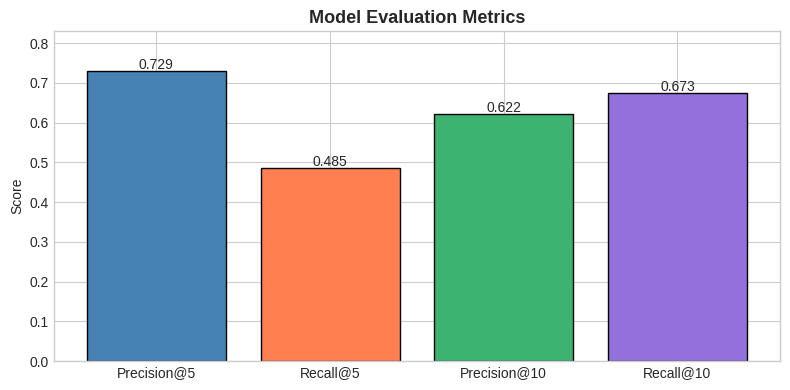

In [ ]:
def precision_at_k(predictions, k=10, threshold=3.5):
    """
    Compute Precision@K and Recall@K for the SVD model.
    A recommendation is considered 'relevant' if predicted rating >= threshold.
    """
    user_preds = {}
    for uid, iid, true_r, est, _ in predictions:
        if uid not in user_preds:
            user_preds[uid] = []
        user_preds[uid].append((est, true_r))

    precisions, recalls = {}, {}
    for uid, user_ratings in user_preds.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]

        n_relevant_k = sum(1 for est, true_r in top_k if true_r >= threshold)
        n_relevant    = sum(1 for est, true_r in user_ratings if true_r >= threshold)

        precisions[uid] = n_relevant_k / k
        recalls[uid]    = n_relevant_k / n_relevant if n_relevant > 0 else 0

    avg_precision = sum(precisions.values()) / len(precisions)
    avg_recall    = sum(recalls.values()) / len(recalls)
    return avg_precision, avg_recall


prec_5,  rec_5  = precision_at_k(predictions, k=5)
prec_10, rec_10 = precision_at_k(predictions, k=10)

print('📊 Precision & Recall Evaluation')
print(f'  Precision@5  : {prec_5:.4f}')
print(f'  Recall@5     : {rec_5:.4f}')
print(f'  Precision@10 : {prec_10:.4f}')
print(f'  Recall@10    : {rec_10:.4f}')

# Visualize
metrics = ['Precision@5', 'Recall@5', 'Precision@10', 'Recall@10']
values  = [prec_5, rec_5, prec_10, rec_10]

plt.figure(figsize=(8, 4))
bars = plt.bar(metrics, values, color=['steelblue','coral','mediumseagreen','mediumpurple'], edgecolor='black')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=10)
plt.title('Model Evaluation Metrics', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, max(values) + 0.1)
plt.tight_layout()
plt.savefig(f'{PROCESSED_PATH}evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# SECTION 12: Save All Model Artifacts

In [ ]:
import joblib
import pickle

# 1. Save TF-IDF vectorizer
joblib.dump(tfidf, f'{MODELS_PATH}tfidf_vectorizer.pkl')
print('✅ Saved: tfidf_vectorizer.pkl')

# 2. Save TF-IDF matrix
joblib.dump(tfidf_matrix, f'{MODELS_PATH}tfidf_matrix.pkl')
print('✅ Saved: tfidf_matrix.pkl')

# 3. Save cosine similarity matrix
joblib.dump(cosine_sim, f'{MODELS_PATH}cosine_sim.pkl')
print('✅ Saved: cosine_sim.pkl')

# 4. Save SVD model
joblib.dump(svd_model, f'{MODELS_PATH}svd_model.pkl')
print('✅ Saved: svd_model.pkl')

# 5. Save title-to-index mapping
joblib.dump(title_to_idx, f'{MODELS_PATH}title_to_idx.pkl')
print('✅ Saved: title_to_idx.pkl')

# 6. Save merged movies dataframe
joblib.dump(merged_df, f'{MODELS_PATH}merged_df.pkl')
print('✅ Saved: merged_df.pkl')

print('\n All model artifacts saved successfully!')
print(f'\nModels directory: {MODELS_PATH}')
print('Contents:')
for f in os.listdir(MODELS_PATH):
    size = os.path.getsize(f'{MODELS_PATH}{f}') / (1024*1024)
    print(f'  {f}  ({size:.1f} MB)')

✅ Saved: tfidf_vectorizer.pkl
✅ Saved: tfidf_matrix.pkl
✅ Saved: cosine_sim.pkl
✅ Saved: svd_model.pkl
✅ Saved: title_to_idx.pkl
✅ Saved: merged_df.pkl

 All model artifacts saved successfully!

Models directory: /content/drive/MyDrive/movie_recommender/models/
Contents:
  tfidf_vectorizer.pkl  (0.2 MB)
  tfidf_matrix.pkl  (0.8 MB)
  cosine_sim.pkl  (838.3 MB)
  svd_model.pkl  (10.1 MB)
  title_to_idx.pkl  (0.6 MB)
  merged_df.pkl  (1.4 MB)


# SECTION 13: Final Summary

In [ ]:
print('=' * 55)
print('   MOVIE RECOMMENDATION SYSTEM — PIPELINE COMPLETE')
print('=' * 55)
print(f'\n📦 Dataset Summary:')
print(f'   African movies (IMDb scraped) : {len(af_clean):,}')
print(f'   MovieLens movies              : {len(ml_clean):,}')
print(f'   Merged total                  : {len(merged_df):,}')
print(f'   User ratings                  : {len(ratings_df):,}')
print(f'   Unique users                  : {ratings_df["userId"].nunique():,}')

print(f'\n🤖 Models Trained:')
print(f'   Content-Based (TF-IDF + Cosine Similarity)')
print(f'   Collaborative Filtering (SVD)')
print(f'   Hybrid Recommender (CBF 40% + CF 60%)')

print(f'\n📊 Model Performance:')
print(f'   RMSE         : {rmse:.4f}')
print(f'   MAE          : {mae:.4f}')
print(f'   Precision@10 : {prec_10:.4f}')
print(f'   Recall@10    : {rec_10:.4f}')

print(f'\n💾 Saved Artifacts:')
print('   models/tfidf_vectorizer.pkl')
print('   models/tfidf_matrix.pkl')
print('   models/cosine_sim.pkl')
print('   models/svd_model.pkl')
print('   models/title_to_idx.pkl')
print('   models/merged_df.pkl')
print('   data/processed/movies_merged.csv')
print('   data/processed/ratings_clean.csv')

print(f'\n Next Step: Building FastAPI backend → api/main.py')
print('=' * 55)

   MOVIE RECOMMENDATION SYSTEM — PIPELINE COMPLETE

📦 Dataset Summary:
   African movies (IMDb scraped) : 499
   MovieLens movies              : 10,329
   Merged total                  : 10,482
   User ratings                  : 105,339
   Unique users                  : 668

🤖 Models Trained:
   Content-Based (TF-IDF + Cosine Similarity)
   Collaborative Filtering (SVD)
   Hybrid Recommender (CBF 40% + CF 60%)

📊 Model Performance:
   RMSE         : 0.8671
   MAE          : 0.6719
   Precision@10 : 0.6223
   Recall@10    : 0.6734

💾 Saved Artifacts:
   models/tfidf_vectorizer.pkl
   models/tfidf_matrix.pkl
   models/cosine_sim.pkl
   models/svd_model.pkl
   models/title_to_idx.pkl
   models/merged_df.pkl
   data/processed/movies_merged.csv
   data/processed/ratings_clean.csv

 Next Step: Building FastAPI backend → api/main.py
